# 130. Transformer model for language understanding

# Transformer model

- Portugal - English translation  

- text genertion 및 attention 이 선수 지식임  

- Transformer model 의 핵심 idea 는 self-attention  

- Transformer 는 self-attention layer 를 쌓아서 구성 (RNN, CNN 사용 않음)    
    - Scaled dot product attention
    - Multi-head attention

- stacked attention layer 의 장점  
    - data 간의 시간적, 공간적 관계를 배제하여 multi-processing 가능  
    - RNN, CNN layer 를 거치지 않아도, 떨어져 있는 item 들이 서로의 output 에 영향을 끼칠 수 있다.
    - 긴 문장내의 상호 관계를 학습할 수 있다. (모든 sequential task 의 도전 과제)  
    
- 단점  
    - 시계열 자료의 경우 RNN 처럼 특정 time-step 의 output 계산을 위해서는 input 과 현재의 hidden state 만으로는 안되고 전체 history 가 있어야 함
    - 단어의 위치 정보를 추가해 주어야 한다. (positional encoding)

이 노트에서 모델을 학습 한 후 포르투갈어 문장을 입력하고 영어 번역을 반환 할 수 있음.

<img src="https://www.tensorflow.org/images/tutorials/transformer/attention_map_portuguese.png" width="800" alt="Attention heatmap">

In [0]:
import tensorflow_datasets as tfds
import tensorflow as tf

import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tf.__version__

'2.2.0-rc3'

## Setup input pipeline

[TFDS](https://www.tensorflow.org/datasets) 를 이용하여 [TED Talks Open Translation Project](https://www.ted.com/participate/translate) 로 부터 [Portugese-English translation dataset](https://github.com/neulab/word-embeddings-for-nmt) 을 load.

dataset 은 약 50000 개의 training example 과 1100 개의 validation examples, 2000 개의 test example 로 구성


In [3]:
examples, metadata = tfds.load('ted_hrlr_translate/pt_to_en', with_info=True,
                               as_supervised=True)
train_examples, val_examples = examples['train'], examples['validation']

Shuffling and writing examples to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0.incompleteW7UO25/ted_hrlr_translate-train.tfrecord


Shuffling and writing examples to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0.incompleteW7UO25/ted_hrlr_translate-validation.tfrecord


Shuffling and writing examples to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0.incompleteW7UO25/ted_hrlr_translate-test.tfrecord


Dataset ted_hrlr_translate downloaded and prepared to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0. Subsequent calls will reuse this data.


In [4]:
for k, v in metadata.splits.items():
    print(f'{k}: {v.num_examples}')

test: 1803
train: 51785
validation: 1193


training dataset 으로부터 subwords tokenizer 생성

In [5]:
%%time
tokenizer_en = tfds.features.text.SubwordTextEncoder.build_from_corpus(
    (en.numpy() for pt, en in train_examples), target_vocab_size=2**13)

tokenizer_pt = tfds.features.text.SubwordTextEncoder.build_from_corpus(
    (pt.numpy() for pt, en in train_examples), target_vocab_size=2**13)

CPU times: user 2min 16s, sys: 7.17 s, total: 2min 23s
Wall time: 2min 8s


In [6]:
print(tokenizer_en.vocab_size)
print(tokenizer_pt.vocab_size)

8087
8214


In [7]:
sample_string = 'Transformer is awesome.'

tokenized_string = tokenizer_en.encode(sample_string)
print ('Tokenized string is {}'.format(tokenized_string))

original_string = tokenizer_en.decode(tokenized_string)
print ('The original string: {}'.format(original_string))

assert original_string == sample_string           # encoding 과 decoding working  확인

Tokenized string is [7915, 1248, 7946, 7194, 13, 2799, 7877]
The original string: Transformer is awesome.


Tokenizer 는 단어가 사전에없는 경우 문자열을 하위 단어로 분리하여 인코딩함.

In [8]:
for ts in tokenized_string:
  print ('{} ----> {}'.format(ts, tokenizer_en.decode([ts])))

7915 ----> T
1248 ----> ran
7946 ----> s
7194 ----> former 
13 ----> is 
2799 ----> awesome
7877 ----> .


- input 과 target 에 start, end token 추가  

    - start : vocab_size  
    - end : vocab_size + 1

In [0]:
def encode(lang1, lang2):
  lang1 = [tokenizer_pt.vocab_size] + tokenizer_pt.encode(
      lang1.numpy()) + [tokenizer_pt.vocab_size+1]

  lang2 = [tokenizer_en.vocab_size] + tokenizer_en.encode(
      lang2.numpy()) + [tokenizer_en.vocab_size+1]
  
  return lang1, lang2

Dataset.map을 사용하여 이 함수를 데이터 세트의 각 요소에 적용.   

Dataset.map은 그래프 모드에서 실행되므로,
- 그래프 텐서에는 값이 없고,
- 그래프 모드에서는 TensorFlow Ops 및 기능 만 사용할 수 있으므로, 
- 따라서 이 함수를 직접 .map 할 수 없으므로,  tf.py_function으로 랩핑해야 한다. 

- tf.py_func() 연산자를 사용하면 TensorFlow 그래프 중간에서 임의의 Python 코드를 실행할 수 있다. 이에 해당하는 TensorFlow 연산자가 아직 존재하지 않는 사용자 정의 NumPy 연산자를 래핑하는 경우에 특히 편리.
- 이 함수를 Dataset.map() 함수와 함께 사용하려면 shape과 type을 명시해주어야 한다.
    - shape는 set_shape
    - type은 tf.py_function의 [tf.float32]를 통해 명시

In [0]:
def tf_encode(pt, en):
  result_pt, result_en = tf.py_function(encode, [pt, en], [tf.int64, tf.int64])
  result_pt.set_shape([None])
  result_en.set_shape([None])

  return result_pt, result_en

training 시간을 줄이기 위하여 token 갯수 40 개 이상의 example 은 drop 한다.

In [0]:
MAX_LENGTH = 40

BUFFER_SIZE = 20000
BATCH_SIZE = 64

In [0]:
# x, y 언어의 max_length 가 모두 MAX_LENGTH 이하가 아니면 filtering
def filter_max_length(x, y, max_length=MAX_LENGTH):
  return tf.logical_and(tf.size(x) <= max_length, tf.size(y) <= max_length)

In [0]:
train_dataset = (
    train_examples
    .map(tf_encode) 
    .filter(filter_max_length)
    .cache()        #속도를 올리기 위해 dataset 을 memory 에 cache
    .shuffle(BUFFER_SIZE)
    .padded_batch(BATCH_SIZE)
    .prefetch(tf.data.experimental.AUTOTUNE))

val_dataset = (
    val_examples
    .map(tf_encode)
    .filter(filter_max_length) 
    .padded_batch(BATCH_SIZE))   

validation set  에서 batch 를 하나 가져와 dataset pipeline 이 잘 구성 되었는지 조회.

In [14]:
pt_batch, en_batch = next(iter(val_dataset))
pt_batch, en_batch

(<tf.Tensor: shape=(64, 38), dtype=int64, numpy=
 array([[8214,  342, 3032, ...,    0,    0,    0],
        [8214,   95,  198, ...,    0,    0,    0],
        [8214, 4479, 7990, ...,    0,    0,    0],
        ...,
        [8214,  584,   12, ...,    0,    0,    0],
        [8214,   59, 1548, ...,    0,    0,    0],
        [8214,  118,   34, ...,    0,    0,    0]])>,
 <tf.Tensor: shape=(64, 40), dtype=int64, numpy=
 array([[8087,   98,   25, ...,    0,    0,    0],
        [8087,   12,   20, ...,    0,    0,    0],
        [8087,   12, 5453, ...,    0,    0,    0],
        ...,
        [8087,   18, 2059, ...,    0,    0,    0],
        [8087,   16, 1436, ...,    0,    0,    0],
        [8087,   15,   57, ...,    0,    0,    0]])>)

## Positional encoding

 - 위치 인코딩이 추가되어 문장에서 단어의 상대 위치에 대한 정보를 모델에 제공

- positional encoding 벡터를 임베딩 벡터에 추가하면 d 차원 공간에서 단어의 의미와 문장에서의 위치의 유사성에 따라 단어가 서로 더 가깝게 된다.

- [positional encoding](https://github.com/tensorflow/examples/blob/master/community/en/position_encoding.ipynb) 에서 추가 정보 조회. 위치 인코딩을 계산하는 공식은 다음과 같다.

$$\Large{PE_{(pos, 2i)} = sin(pos / 10000^{2i / d_{model}})} $$
$$\Large{PE_{(pos, 2i+1)} = cos(pos / 10000^{2i / d_{model}})} $$
    - d_model : embedding vector 의 차원 (512), pos : 입력문장의 단어 순서 위치, i : embedding vector 내의 차원의 index

In [0]:
def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
  return pos * angle_rates

In [0]:
def positional_encoding(position, d_model):
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                          np.arange(d_model)[np.newaxis, :],
                          d_model)
  
  # 짝수 위치 (2i) 에는 sin 적용
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  
  # 홀수 위치 (2i) 에는 cos 적용
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
  pos_encoding = angle_rads[np.newaxis, ...]
    
  return tf.cast(pos_encoding, dtype=tf.float32)

In [0]:
def plot_positional_encoding(ax, position, d_model):
    pos_encoding = positional_encoding(position, d_model)
    print (pos_encoding.shape)

    im = ax.pcolormesh(pos_encoding[0], cmap='RdBu')
    ax.set_xlabel('Depth')
    ax.set_xlim((0, 512))
    ax.set_ylabel('Position')
    ax.set_title(f'position: {position}')
    fig.colorbar(im, ax=ax)

(1, 50, 512)


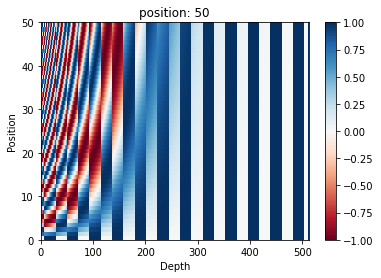

In [18]:
fig, ax = plt.subplots(1, 1)
plot_positional_encoding(ax, 50, 512)

(1, 3, 512)
(1, 8, 512)
(1, 13, 512)
(1, 18, 512)
(1, 23, 512)
(1, 28, 512)
(1, 33, 512)
(1, 38, 512)
(1, 43, 512)
(1, 48, 512)
(1, 53, 512)
(1, 58, 512)


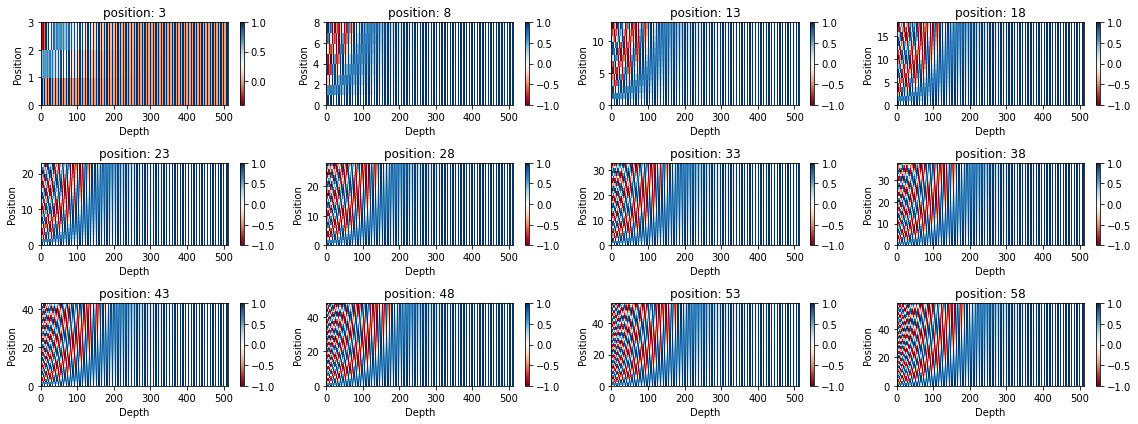

In [29]:
fig, axes = plt.subplots(3, 4, figsize=(16, 6))
axes = axes.ravel()

for i in range(len(axes)):
    plot_positional_encoding(axes[i], i*5+3, 512)
    
plt.tight_layout()

## Masking

#### PAD Mask
- sequence batch  내의 모든 패드 토큰 (0) 을 마스킹. 
- 이렇게 하면 모델이 패딩을 입력으로 처리하지 않는다. 
- 마스크는 패드 값 '0'이있는 위치를 나타낸다.
- 해당 위치에서 '1'을 출력하고 그렇지 않으면 '0'을 출력한다.

In [0]:
def create_padding_mask(seq):
  seq = tf.cast(tf.math.equal(seq, 0), tf.float32)    # integer 0 을 float32 로 type 변환
  # padding 을 추가하기 위해 extra dimension 을 attention logit 에 추가
  return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

상수 tensor 를 생성하여 위 함수를 Test

In [20]:
x = tf.constant([[7, 6, 0, 0, 1], [1, 2, 3, 0, 0], [0, 0, 0, 4, 5]])  
create_padding_mask(x)

<tf.Tensor: shape=(3, 1, 1, 5), dtype=float32, numpy=
array([[[[0., 0., 1., 1., 0.]]],


       [[[0., 0., 0., 1., 1.]]],


       [[[1., 1., 1., 0., 0.]]]], dtype=float32)>

#### look-ahead 마스크
-  미래의 토큰을 순서대로 마스킹하는 데 사용. 
- 즉, 마스크는 사용하지 말아야 할 항목을 나타냄.
- 이는 세 번째 단어를 예측하기 위해 첫 번째와 두 번째 단어 만 사용됨을 의미한다. 
- 네 번째 단어를 예측하려면 마찬가지로 첫 번째, 두 번째 및 세 번째 단어 만 사용된다.

In [21]:
tf.linalg.band_part(tf.ones((4, 4)), -1, 0)  # Lower triangular part 를 남기고 1 로 변환

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 1., 0., 0.],
       [1., 1., 1., 0.],
       [1., 1., 1., 1.]], dtype=float32)>

In [0]:
def create_look_ahead_mask(size):
  mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
  return mask    # (seq_len, seq_len)

## Scaled dot product attention

<img src="https://www.tensorflow.org/images/tutorials/transformer/scaled_attention.png" width="500" alt="scaled_dot_product_attention">

- 트랜스포머에서 사용되는 attention 함수의 입력은 Q (쿼리), K (키), V (값)의 세 가지 벡터이다. 
- attention weight 를 계산하는 데 사용되는 방정식은 다음과 같다.

$$\Large{Attention(Q, K, V) = softmax_k(\frac{QK^T}{\sqrt{d_k}}) V} $$

- dot-product attention 은 embedding dimension의 제곱근에 의해 scaling 된다. 이는 dot product 값이 커질 수록 소프트 맥스 함수에 집어넣으면 기울기를 얻기 힘들기 때문.

- mask 에 -1e9(음의 무한대에 가까움) 을 곱하여 Q와 K의 스케일 된 행렬 곱셈 (scaled-attention-logit) 에 더한다.  이렇게 하면 mask 가 1 인 경우는 softmax에 큰 음의 입력값을 주게 되고 출력이 0 이 되기 때문이다.
즉, mask 가 1 인 경우는 예측을 하면 안되기 때문이다.

In [0]:
def scaled_dot_product_attention(q, k, v, mask):
  """attention weights 계산
  q, k, v 의 첫번째 dimension 은 같아야 함
  k, v 는  두번째 dimension 이 같아야 함, i.e.: seq_len_k = seq_len_v.
  mask 는  type(padding or look ahead) 에 다라 다른 shape 을 가진다.
  그러나 addition 할 때에  broadcastable 하다.
  
  Args:
    q: query shape == (..., seq_len_q, depth)
    k: key shape == (..., seq_len_k, depth)
    v: value shape == (..., seq_len_v, depth_v)
    mask: Float tensor with shape broadcastable 
          to (..., seq_len_q, seq_len_k). Defaults to None.
    
  Returns:
    output, attention_weights
  """

  matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)
  
  # scale matmul_qk
  dk = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

  # scaled tensor 에 (mask * -1e9) 를 더함
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)  

  # ast axis (seq_len_k) 를 기준으로 softmax 가 normalized 됨. scores 의 합은 1
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

  output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)

  return output, attention_weights

- 소프트 맥스 정규화가 K에서 수행 될 때, 그 값은 Q에 주어진 중요도를 결정하고, 그 출력값은 attention weight 와 V (값) 벡터의 곱을 나타낸다. 이렇게하면 attention 하려는 단어는 그대로 유지되고 관련이없는 단어는 지워진다.

In [0]:
def print_out(q, k, v):
  temp_out, temp_attn = scaled_dot_product_attention(q, k, v, None)

  print ('Output is:')
  print (temp_out)
  print ('Attention weights are:')
  print (temp_attn)

In [25]:
np.set_printoptions(suppress=True)

temp_k = tf.constant([
                      [10,0,0],
                      [0,10,0],
                      [0,0,10],
                      [0,0,10]], dtype=tf.float32)  # (4, 3)

temp_v = tf.constant([
                      [ 1,0, 0],
                      [ 10,0, 0],
                      [ 100,5, 0],
                      [1000,6, 0]], dtype=tf.float32)  # (4, 3)

# 두번째 `key`를 `query` 하므로 두번째 `value` 가 attentin weight 1 로 반환
temp_q = tf.constant([[0, 10, 0]], dtype=tf.float32)  # (1, 3)
print_out(temp_q, temp_k, temp_v)

Output is:
tf.Tensor([[10.  0.  0.]], shape=(1, 3), dtype=float32)
Attention weights are:
tf.Tensor([[0. 1. 0. 0.]], shape=(1, 4), dtype=float32)


In [26]:
# 반복되는 key (third and fourth) 를 query 하므로, 연관된 값의 평균 반환
temp_q = tf.constant([[0, 0, 10]], dtype=tf.float32)  # (1, 3)
print_out(temp_q, temp_k, temp_v)

Output is:
tf.Tensor([[550.    5.5   0. ]], shape=(1, 3), dtype=float32)
Attention weights are:
tf.Tensor([[0.  0.  0.5 0.5]], shape=(1, 4), dtype=float32)


In [27]:
# 첫번째와 두번째 key 를 동등하게 query 하므로, 평균값 반환
temp_q = tf.constant([[10, 10, 0]], dtype=tf.float32)  # (1, 3)
print_out(temp_q, temp_k, temp_v)

Output is:
tf.Tensor([[5.5 0.  0. ]], shape=(1, 3), dtype=float32)
Attention weights are:
tf.Tensor([[0.5 0.5 0.  0. ]], shape=(1, 4), dtype=float32)


모든 쿼리를 함께 전달.

In [28]:
temp_q = tf.constant([[0, 0, 10], [0, 10, 0], [10, 10, 0]], dtype=tf.float32)  # (3, 3)
print_out(temp_q, temp_k, temp_v)

Output is:
tf.Tensor(
[[550.    5.5   0. ]
 [ 10.    0.    0. ]
 [  5.5   0.    0. ]], shape=(3, 3), dtype=float32)
Attention weights are:
tf.Tensor(
[[0.  0.  0.5 0.5]
 [0.  1.  0.  0. ]
 [0.5 0.5 0.  0. ]], shape=(3, 4), dtype=float32)


## Multi-head attention

<img src="https://www.tensorflow.org/images/tutorials/transformer/multi_head_attention.png" width="500" alt="multi-head attention">


멀티 헤드 attention 은 다음 네 부분으로 구성됩니다.
* linear layer 와 헤드 분할.
* scaled dot-product attention.
* multi-head 의 concatenate.
* 최종 linear layer.

각 멀티 헤드 어텐션 블록에는 Q (쿼리), K (키), V (값) 의 3 개의 입력이 있다. 이들은 선형 (Dense) 레이어를 통해 여러 헤드로 분할된다.

위에서 정의한`scaled_dot_product_attention`은 각 헤드에 적용.(효율성을 위해 broadcast 됨). attention 단계에서 적절한 마스크를 사용해야 한다. 그런 다음 각 헤드에 대한 attention output 이 연결되고 ( 'tf.transpose'및 'tf.reshape'사용) 최종`Dense` 레이어를 통과.

하나의 단일 attention head 를 사용 않고, Q, K 및 V는 여러 헤드로 분할되어 모델이 서로 다른 표현 공간의 다른 위치에있는 정보에 공동으로 attend 할 수 있게한다. 분할 후 각 헤드의 dimension 이 감소하므로 전체 계산 비용은 전체 dimension 으로 단일 head attention 할 때와 같다.

In [0]:
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.num_heads = num_heads
    self.d_model = d_model
    
    assert d_model % self.num_heads == 0
    
    self.depth = d_model // self.num_heads 
    
    # Linear Layer
    self.wq = tf.keras.layers.Dense(d_model)
    self.wk = tf.keras.layers.Dense(d_model)
    self.wv = tf.keras.layers.Dense(d_model)
    
    self.dense = tf.keras.layers.Dense(d_model)
        
  def split_heads(self, x, batch_size):
    """ last dimension 을 (num_heads, depth) 로 split.
         shape 이 (batch_size, num_heads, seq_len, depth) 가 되도록 결과를 transpose
    """
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0, 2, 1, 3])
    
  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]
    
    q = self.wq(q)  # (batch_size, seq_len, d_model)
    k = self.wk(k)  # (batch_size, seq_len, d_model)
    v = self.wv(v)  # (batch_size, seq_len, d_model)
    
    q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
    k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
    v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)
    
    # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
    # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)
    scaled_attention, attention_weights = scaled_dot_product_attention(
        q, k, v, mask)
    
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

    concat_attention = tf.reshape(scaled_attention, 
                                  (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

    output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)
        
    return output, attention_weights

`y` 시퀀스의 각 위치에서 `MultiHeadAttention` 은 시퀀스의 다른 모든 위치에 8 개의 attention head 를 모두 실행하여 각 위치에서 동일한 길이의 새 벡터를 반환.

In [39]:
temp_mha = MultiHeadAttention(d_model=512, num_heads=8)
y = tf.random.uniform((1, 50, 512))  # (batch_size, encoder_sequence, d_model)
out, attn = temp_mha(y, k=y, q=y, mask=None)
out.shape, attn.shape

(TensorShape([1, 50, 512]), TensorShape([1, 8, 50, 50]))

## Point wise feed forward network

포인트 단위 피드 포워드 네트워크는 ReLU 활성화를 통해 두 개의 완전히 연결 레이어로 구성된다.

In [0]:
def point_wise_feed_forward_network(d_model, dff):
  return tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),   # (batch_size, seq_len, dff)
      tf.keras.layers.Dense(d_model)                    # (batch_size, seq_len, d_model)
  ])

In [38]:
sample_ffn = point_wise_feed_forward_network(512, 2048)
sample_ffn(tf.random.uniform((64, 50, 512))).shape

TensorShape([64, 50, 512])

## Encoder and decoder

<img src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png" width="600" alt="transformer">

transformer model 은  표준 `sequence to sequence with attention model` 과 동일한 일반적 pattern 을 따른다.(nmt_with_attention.ipynb). 

* 입력 문장은 시퀀스의 각 단어 / 토큰에 대한 출력을 생성하는 N 개의 인코더 레이어를 통과한다.
* 디코더는 다음 단어 예측을 위해 인코더의 출력과 자체의 입력 (self-attention)에 attend 합니다.

### Encoder layer

각 encoder layer 는 sublayer 들로 구성:

1.   Multi-head attention (with padding mask) 
2.   Point wise feed forward networks. 

이들 서브 계층들 각각은 그 주변을 돌아가는 residual connection(잔차 연결)을 갖고 있어서 layer normalization 을 한다. 잔차 연결은 딥 네트워크에서의 vanishing gradient 문제를 방지하는 데 도움이 된다.

각 sublayer 의 output 은 `LayerNorm(x + Sublayer(x))` 이다. normalization 은 `d_model` (last) axis 에 대해 이루어 진다. transformer 는 N encoder layer 로 구성된다.

In [0]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(EncoderLayer, self).__init__()

    self.mha = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)

    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    
    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)
    
  def call(self, x, training, mask):

    attn_output, _ = self.mha(x, x, x, mask)  # (batch_size, input_seq_len, d_model)
    attn_output = self.dropout1(attn_output, training=training)
    out1 = self.layernorm1(x + attn_output)  # (batch_size, input_seq_len, d_model)
    
    ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
    ffn_output = self.dropout2(ffn_output, training=training)
    out2 = self.layernorm2(out1 + ffn_output)  # (batch_size, input_seq_len, d_model)
    
    return out2

In [41]:
sample_encoder_layer = EncoderLayer(512, 8, 2048)

sample_encoder_layer_output = sample_encoder_layer(
    tf.random.uniform((64, 43, 512)), False, None)

sample_encoder_layer_output.shape  # (batch_size, input_seq_len, d_model)

TensorShape([64, 43, 512])

### Decoder layer

각 decoder layer 는 다음의 sublayer 들로 구성:

1.   Masked multi-head attention (look ahead mask 와 padding mask 로 구성)
2.   Multi-head attention (with padding mask). V (value) and K (key)  *encoder output* 을 inputs 으로 받는다. Q (query) 는  *masked multi-head attention sublayer 의 output* 을 input 으로 받는다.
3.   Point wise feed forward networks

이들 서브 계층들 각각은 그 주변에 residual connection(잔차 연결) 을 갖고 이어서 layer normalization dmf 갖는다. 각 sublayer 의 output 은 `LayerNorm(x + Sublayer(x))` 이다. normalization 은 d_model (last) axis 에 대해 이루어 진다.

Transformer 는 N encoder layer 로 구성된다.

Q는 디코더의 첫 번째 attention 블록에서 출력을 수신하고 K가 인코더 출력을 수신함에 따라 attention weight 는 인코더의 출력을 기반으로 디코더의 입력에 주어진 중요성을 나타낸다. 다시 말해, 디코더는 엔코더 출력을보고 자체 출력에 self attention 하여 다음 단어를 예측한다. 


In [0]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(DecoderLayer, self).__init__()

    self.mha1 = MultiHeadAttention(d_model, num_heads)
    self.mha2 = MultiHeadAttention(d_model, num_heads)

    self.ffn = point_wise_feed_forward_network(d_model, dff)
 
    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    
    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)
    self.dropout3 = tf.keras.layers.Dropout(rate)
    
    
  def call(self, x, enc_output, training, 
           look_ahead_mask, padding_mask):
    # enc_output.shape == (batch_size, input_seq_len, d_model)

    attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)  # (batch_size, target_seq_len, d_model)
    attn1 = self.dropout1(attn1, training=training)
    out1 = self.layernorm1(attn1 + x)
    
    attn2, attn_weights_block2 = self.mha2(
        enc_output, enc_output, out1, padding_mask)  # (batch_size, target_seq_len, d_model)
    attn2 = self.dropout2(attn2, training=training)
    out2 = self.layernorm2(attn2 + out1)  # (batch_size, target_seq_len, d_model)
    
    ffn_output = self.ffn(out2)  # (batch_size, target_seq_len, d_model)
    ffn_output = self.dropout3(ffn_output, training=training)
    out3 = self.layernorm3(ffn_output + out2)  # (batch_size, target_seq_len, d_model)
    
    return out3, attn_weights_block1, attn_weights_block2

In [43]:
sample_decoder_layer = DecoderLayer(512, 8, 2048)

sample_decoder_layer_output, _, _ = sample_decoder_layer(
    tf.random.uniform((64, 50, 512)), sample_encoder_layer_output, 
    False, None, None)

sample_decoder_layer_output.shape  # (batch_size, target_seq_len, d_model)

TensorShape([64, 50, 512])

### Encoder 전체

전체 `Encoder` 는 다음으로 구성:
1.   Input Embedding
2.   Positional Encoding
3.   N encoder layers

입력은 positional 인코딩과 합쳐진 임베딩을 통해 이루어진다. 이 합산의 출력은 인코더 계층에 대한 입력이다. 인코더의 출력은 디코더에 대한 입력이다.

In [0]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
               maximum_position_encoding, rate=0.1):
    super(Encoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers
    
    self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, 
                                            self.d_model)
    
    
    self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate) 
                       for _ in range(num_layers)]
  
    self.dropout = tf.keras.layers.Dropout(rate)
        
  def call(self, x, training, mask):

    seq_len = tf.shape(x)[1]
    
    # adding embedding and position encoding.
    x = self.embedding(x)  # (batch_size, input_seq_len, d_model)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]

    x = self.dropout(x, training=training)
    
    for i in range(self.num_layers):
      x = self.enc_layers[i](x, training, mask)
    
    return x  # (batch_size, input_seq_len, d_model)

In [45]:
sample_encoder = Encoder(num_layers=2, d_model=512, num_heads=8, 
                         dff=2048, input_vocab_size=8500,
                         maximum_position_encoding=10000)
temp_input = tf.random.uniform((64, 62), dtype=tf.int64, minval=0, maxval=200)

sample_encoder_output = sample_encoder(temp_input, training=False, mask=None)

print (sample_encoder_output.shape)  # (batch_size, input_seq_len, d_model)

(64, 62, 512)


### Decoder 전체

전체 `Decoder` 는 다음으로 구성:
1.   Output Embedding
2.   Positional Encoding
3.   N decoder layers

타겟은 positional 인코딩과 합산 된 임베딩을 통해 이루어진다. 이 합산의 출력은 디코더 층에 대한 입력이다. 디코더의 출력은 최종 linear layer 에 대한 입력이다.

In [0]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
               maximum_position_encoding, rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers
    
    self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
    
    self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate) 
                       for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(rate)
    
  def call(self, x, enc_output, training, 
           look_ahead_mask, padding_mask):

    seq_len = tf.shape(x)[1]
    attention_weights = {}
    
    x = self.embedding(x)  # (batch_size, target_seq_len, d_model)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]
    
    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x, block1, block2 = self.dec_layers[i](x, enc_output, training,
                                             look_ahead_mask, padding_mask)
      
      attention_weights['decoder_layer{}_block1'.format(i+1)] = block1
      attention_weights['decoder_layer{}_block2'.format(i+1)] = block2
    
    # x.shape == (batch_size, target_seq_len, d_model)
    return x, attention_weights

In [47]:
sample_decoder = Decoder(num_layers=2, d_model=512, num_heads=8, 
                         dff=2048, target_vocab_size=8000,
                         maximum_position_encoding=5000)
temp_input = tf.random.uniform((64, 26), dtype=tf.int64, minval=0, maxval=200)

output, attn = sample_decoder(temp_input, 
                              enc_output=sample_encoder_output, 
                              training=False,
                              look_ahead_mask=None, 
                              padding_mask=None)

output.shape, attn['decoder_layer2_block2'].shape

(TensorShape([64, 26, 512]), TensorShape([64, 8, 26, 62]))

## Transformer 생성

Transformer 는 인코더, 디코더 및 최종 linear layer 로 구성. 디코더의 출력은 linear layer 에 대한 입력이며 출력이 반환된다.

In [0]:
class Transformer(tf.keras.Model):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, 
               target_vocab_size, pe_input, pe_target, rate=0.1):
    super(Transformer, self).__init__()

    self.encoder = Encoder(num_layers, d_model, num_heads, dff, 
                           input_vocab_size, pe_input, rate)

    self.decoder = Decoder(num_layers, d_model, num_heads, dff, 
                           target_vocab_size, pe_target, rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)
    
  def call(self, inp, tar, training, enc_padding_mask, 
           look_ahead_mask, dec_padding_mask):

    enc_output = self.encoder(inp, training, enc_padding_mask)  # (batch_size, inp_seq_len, d_model)
    
    # dec_output.shape == (batch_size, tar_seq_len, d_model)
    dec_output, attention_weights = self.decoder(
        tar, enc_output, training, look_ahead_mask, dec_padding_mask)
    
    final_output = self.final_layer(dec_output)  # (batch_size, tar_seq_len, target_vocab_size)
    
    return final_output, attention_weights

In [49]:
sample_transformer = Transformer(
    num_layers=2, d_model=512, num_heads=8, dff=2048, 
    input_vocab_size=8500, target_vocab_size=8000, 
    pe_input=10000, pe_target=6000)

temp_input = tf.random.uniform((64, 38), dtype=tf.int64, minval=0, maxval=200)
temp_target = tf.random.uniform((64, 36), dtype=tf.int64, minval=0, maxval=200)

fn_out, _ = sample_transformer(temp_input, temp_target, training=False, 
                               enc_padding_mask=None, 
                               look_ahead_mask=None,
                               dec_padding_mask=None)

fn_out.shape  # (batch_size, tar_seq_len, target_vocab_size)

TensorShape([64, 36, 8000])

## Set hyperparameters

이 예제를 작고 비교적 빠르게 유지하기 위해 *num_layers, d_model 및 dff* 의 값을 줄임. 

transformer  기본 모델에 사용 된 값은; *num_layers=6*, *d_model = 512*, *dff = 2048*. 

참고 : 아래 값을 변경하면 많은 작업에서 최첨단 모델을 얻을 수 있다.

In [0]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8

input_vocab_size = tokenizer_pt.vocab_size + 2
target_vocab_size = tokenizer_en.vocab_size + 2
dropout_rate = 0.1

## Optimizer

[paper](https://arxiv.org/abs/1706.03762) 의 공식에 따라 custom learning rate scheduler 와 함께 Adam optimizer 를 사용하십시오.



$$\Large{lrate = d_{model}^{-0.5} * min(step{\_}num^{-0.5}, step{\_}num * warmup{\_}steps^{-1.5})}$$


In [0]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super(CustomSchedule, self).__init__()
    
    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps
    
  def __call__(self, step):
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)
    
    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [0]:
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, 
                                     epsilon=1e-9)

Text(0.5, 0, 'Train Step')

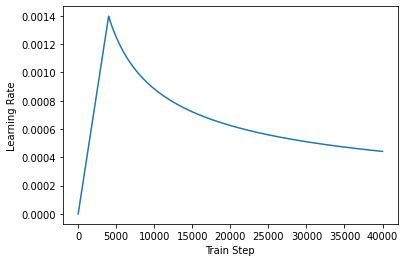

In [53]:
temp_learning_rate_schedule = CustomSchedule(d_model)

plt.plot(temp_learning_rate_schedule(tf.range(40000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")

## Loss and metrics

target sequences 가 padding 되어 있으므로, loss 계산 시 padding mask 를 적용하는 것이 중요.

tf.keras.losses.SparseCategoricalCrossentropy 의 reduction=NONE 으로 지정할 경우는 shape 이 [batch_size, d0, .. dN-1] 이고, 그렇지 않은 경우는 scalar 이다.

In [0]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

In [0]:
def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask
  
  return tf.reduce_mean(loss_)

In [0]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(
    name='train_accuracy')

## Training and checkpointing

In [0]:
transformer = Transformer(num_layers, d_model, num_heads, dff,
                          input_vocab_size, target_vocab_size, 
                          pe_input=input_vocab_size, 
                          pe_target=target_vocab_size,
                          rate=dropout_rate)

In [0]:
def create_masks(inp, tar):
  # Encoder padding mask
  enc_padding_mask = create_padding_mask(inp)
  
  # Used in the 2nd attention block in the decoder.
  # This padding mask is used to mask the encoder outputs.
  dec_padding_mask = create_padding_mask(inp)
  
  # Used in the 1st attention block in the decoder.
  # It is used to pad and mask future tokens in the input received by 
  # the decoder.
  look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
  dec_target_padding_mask = create_padding_mask(tar)
  combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)
  
  return enc_padding_mask, combined_mask, dec_padding_mask

checkpoint path 및 checkpoint manager 생성. `n` epochs 에서 checkpoint save 에 사용.

In [0]:
checkpoint_path = "./checkpoints/train"

ckpt = tf.train.Checkpoint(transformer=transformer,
                           optimizer=optimizer)

ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# if a checkpoint exists, restore the latest checkpoint.
if ckpt_manager.latest_checkpoint:
  ckpt.restore(ckpt_manager.latest_checkpoint)
  print ('Latest checkpoint restored!!')

target 은 tar_inp와 tar_real로 나뉜다. tar_inp 은 디코더에 입력으로 전달된다. tar_real은 동일한 입력이 1 step 만큼 이동 된 것이다. tar_input 의 각 위치에서 tar_real은 예측해야 할 다음 토큰을 포함한다.

Ex) `sentence` = "SOS A lion in the jungle is sleeping EOS"

`tar_inp` =  "SOS A lion in the jungle is sleeping"

`tar_real` = "A lion in the jungle is sleeping EOS"

변환기는 자동 회귀 모델이다. 한 번에 한 부분 씩 예측하고 그 결과를 사용하여 다음에 수행 할 작업을 결정한다.

During training this example uses teacher-forcing (like in the [text generation tutorial](./text_generation.ipynb)). Teacher forcing is passing the true output to the next time step regardless of what the model predicts at the current time step.

훈련하는 동안은 teacher-forcing 기법 사용 (text generation model 참조) teacher-forcing 은 현재 time step 에서 모델이 예측하는 것과 상관없이 실제 출력을 다음 time step 으로 전달.

Transformer 가 각 단어를 예측할 때 *self-attention* 을 사용하면 입력 시퀀스의 이전 단어를보고 다음 단어를 더 잘 예측할 수 있다.

model 이 expected output 을 미리 엿보는 것을 막기 위해 look-ahead mask 사용.

In [0]:
EPOCHS = 20

In [0]:
# input_signature 를 명시해 주면 tf.function 사용 시 graph 호출 당 1 회만 gradient 를 trace.
train_step_signature = [
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),
]

@tf.function(input_signature=train_step_signature)
def train_step(inp, tar):
  tar_inp = tar[:, :-1]
  tar_real = tar[:, 1:]
  
  enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)
  
  with tf.GradientTape() as tape:
    predictions, _ = transformer(inp, tar_inp, 
                                 True, 
                                 enc_padding_mask, 
                                 combined_mask, 
                                 dec_padding_mask)
    loss = loss_function(tar_real, predictions)

  gradients = tape.gradient(loss, transformer.trainable_variables)    
  optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))
  
  train_loss(loss)
  train_accuracy(tar_real, predictions)

Portugal 어가 input language 이고 English 가 target language 로 사용됨.

In [ ]:
%%time
for epoch in range(EPOCHS):
  start = time.time()
  
  train_loss.reset_states()
  train_accuracy.reset_states()
  
  # inp -> portuguese, tar -> english
  for (batch, (inp, tar)) in enumerate(train_dataset):
    train_step(inp, tar)
    
    if batch % 50 == 0:
      print ('Epoch {} Batch {} Loss {:.4f} Accuracy {:.4f}'.format(
          epoch + 1, batch, train_loss.result(), train_accuracy.result()))
      
  if (epoch + 1) % 5 == 0:
    ckpt_save_path = ckpt_manager.save()
    print ('Saving checkpoint for epoch {} at {}'.format(epoch+1,
                                                         ckpt_save_path))
    
  print ('Epoch {} Loss {:.4f} Accuracy {:.4f}'.format(epoch + 1, 
                                                train_loss.result(), 
                                                train_accuracy.result()))

  print ('Time taken for 1 epoch: {} secs\n'.format(time.time() - start))

## Evaluate

다음 단계에 따라 평가:

* Portuguese tokenizer (`tokenizer_pt`) 를 이용하여 input sentence 를 encode.  또한 시작 및 종료 토큰을 추가하여 입력이 모델이 학습할 당시와 동일하도록 만듭니다. 엔코더 입력입니다.
* decoder 의 input 은 `start token == tokenizer_en.vocab_size` 이다.
* padding masks 와 look ahead masks 를 계산.
* `decoder` 는 `encoder output` 과 자신의 output (self-attention) 을 보면서 output 을 예측함. 
* 마지막 단어를 선택하고 해당 단어의 argmax를 계산. 
* 예측 된 단어를 디코더에 전달하여 디코더 입력에 연결합니다.
* 이 접근 방법으로, 디코더는 예측 된 이전 단어에 기초하여 다음 단어를 예측한다.

Note: 여기에 사용 된 모델은 예제를 비교적 빠르게 수행하기 위해 적은 capacity 를 사용했으므로, 예측이 덜 적합 할 수 있다. 논문의 결과를 재현하려면 위의 하이퍼 파라미터를 변경하여 전체 데이터 세트를 다 사용하고, base Transformer model 또는 Transformer-XL 을 사용.

In [0]:
def evaluate(inp_sentence):
  start_token = [tokenizer_pt.vocab_size]
  end_token = [tokenizer_pt.vocab_size + 1]
  
  # inp sentence 는 portugese 이고, start 및 end token 추가
  inp_sentence = start_token + tokenizer_pt.encode(inp_sentence) + end_token
  encoder_input = tf.expand_dims(inp_sentence, 0)
  
  # target  은 english 이고,  transformer 에 대한 첫번 word 는 start token 이다.
  decoder_input = [tokenizer_en.vocab_size]
  output = tf.expand_dims(decoder_input, 0)
    
  for i in range(MAX_LENGTH):
    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(
        encoder_input, output)
  
    # predictions.shape == (batch_size, seq_len, vocab_size)
    predictions, attention_weights = transformer(encoder_input, 
                                                 output,
                                                 False,
                                                 enc_padding_mask,
                                                 combined_mask,
                                                 dec_padding_mask)
    
    # seq_len dimension 으로부터 마지막 단어 선택 
    predictions = predictions[: ,-1:, :]  # (batch_size, 1, vocab_size)

    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)
    
    # predicted_id 가 end token 이 나오면 결과 반환
    if predicted_id == tokenizer_en.vocab_size+1:
      return tf.squeeze(output, axis=0), attention_weights
    
    # predicted_id 를 output 에 concatenate 하여 decoder 의 input 으로 제공
    output = tf.concat([output, predicted_id], axis=-1)

  return tf.squeeze(output, axis=0), attention_weights

In [0]:
def plot_attention_weights(attention, sentence, result, layer):
  fig = plt.figure(figsize=(16, 8))
  
  sentence = tokenizer_pt.encode(sentence)
  
  attention = tf.squeeze(attention[layer], axis=0)
  
  for head in range(attention.shape[0]):
    ax = fig.add_subplot(2, 4, head+1)
    
    # plot the attention weights
    ax.matshow(attention[head][:-1, :], cmap='viridis')

    fontdict = {'fontsize': 10}
    
    ax.set_xticks(range(len(sentence)+2))
    ax.set_yticks(range(len(result)))
    
    ax.set_ylim(len(result)-1.5, -0.5)
        
    ax.set_xticklabels(
        ['<start>']+[tokenizer_pt.decode([i]) for i in sentence]+['<end>'], 
        fontdict=fontdict, rotation=90)
    
    ax.set_yticklabels([tokenizer_en.decode([i]) for i in result 
                        if i < tokenizer_en.vocab_size], 
                       fontdict=fontdict)
    
    ax.set_xlabel('Head {}'.format(head+1))
  
  plt.tight_layout()
  plt.show()

In [0]:
def translate(sentence, plot=''):
  result, attention_weights = evaluate(sentence)
  
  predicted_sentence = tokenizer_en.decode([i for i in result 
                                            if i < tokenizer_en.vocab_size])  

  print('Input: {}'.format(sentence))
  print('Predicted translation: {}'.format(predicted_sentence))
  
  if plot:
    plot_attention_weights(attention_weights, sentence, result, plot)

In [67]:
translate("este é um problema que temos que resolver.")
print ("Real translation: this is a problem we have to solve .")

Input: este é um problema que temos que resolver.
Predicted translation: this is a problem that we have to solve .
Real translation: this is a problem we have to solve .


In [68]:
translate("os meus vizinhos ouviram sobre esta ideia.")
print ("Real translation: and my neighboring homes heard about this idea .")

Input: os meus vizinhos ouviram sobre esta ideia.
Predicted translation: my neighbors had heard about this idea of this idea as an idea .
Real translation: and my neighboring homes heard about this idea .


In [69]:
translate("vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.")
print ("Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .")

Input: vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.
Predicted translation: so i 'm going to look quickly to share some stories of some magic things that have happened .
Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .


`plot` parameter 에 decoder 의 다른 layer 와 attention block 을 전달.

Input: este é o primeiro livro que eu fiz.
Predicted translation: this is the first book i did .


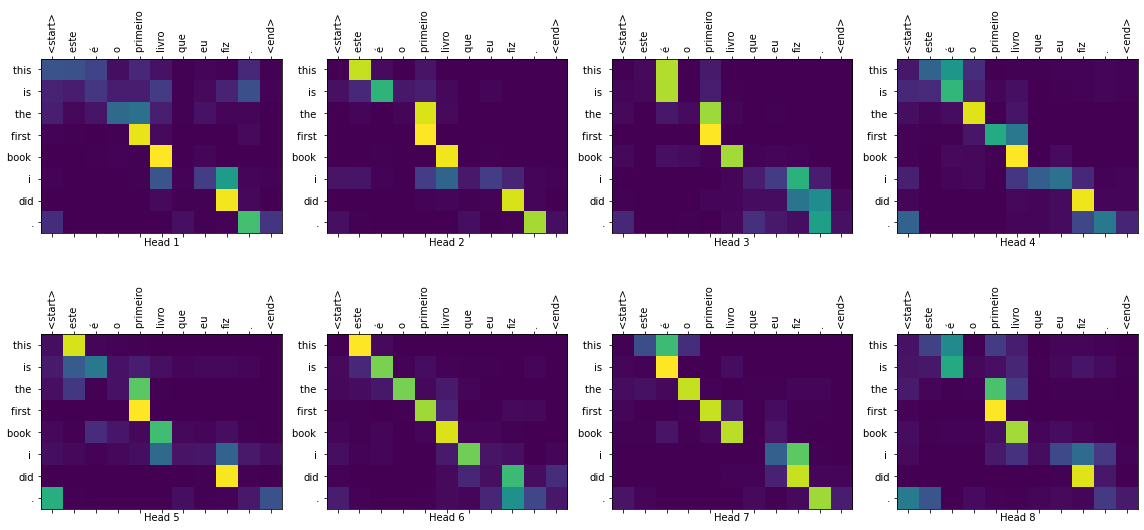

Real translation: this is the first book i've ever done.


In [70]:
translate("este é o primeiro livro que eu fiz.", plot='decoder_layer4_block2')
print ("Real translation: this is the first book i've ever done.")